In [3]:
import pandas as pd 
import matplotlib.pyplot as plt
import numpy as np

# 28 x 28 pixel images
Train = pd.read_csv('data/sign_mnist_train.csv')
Test = pd.read_csv('data/sign_mnist_test.csv')

Train.describe()

,label,pixel1,pixel2,pixel3,pixel4,pixel5,pixel6,pixel7,pixel8,pixel9,...,pixel775,pixel776,pixel777,pixel778,pixel779,pixel780,pixel781,pixel782,pixel783,pixel784
count,27455.000000,27455.000000,27455.000000,27455.000000,27455.000000,27455.000000,27455.000000,27455.000000,27455.000000,27455.000000,...,27455.000000,27455.000000,27455.000000,27455.000000,27455.000000,27455.000000,27455.000000,27455.000000,27455.000000,27455.000000
mean,12.318813,145.419377,148.500273,151.247714,153.546531,156.210891,158.411255,160.472154,162.339683,163.954799,...,141.104863,147.495611,153.325806,159.125332,161.969259,162.736696,162.906137,161.966454,161.137898,159.824731
std,7.287552,41.358555,39.942152,39.056286,38.595247,37.111165,36.125579,35.016392,33.661998,32.651607,...,63.751194,65.512894,64.427412,63.708507,63.738316,63.444008,63.509210,63.298721,63.610415,64.396846
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,6.000000,121.000000,126.000000,130.000000,133.000000,137.000000,140.000000,142.000000,144.000000,146.000000,...,92.000000,96.000000,103.000000,112.000000,120.000000,125.000000,128.000000,128.000000,128.000000,125.500000
50%,13.000000,150.000000,153.000000,156.000000,158.000000,160.000000,162.000000,164.000000,165.000000,166.000000,...,144.000000,162.000000,172.000000,180.000000,183.000000,184.000000,184.000000,182.000000,182.000000,182.000000
75%,19.000000,174.000000,176.000000,178.000000,179.000000,181.000000,182.000000,183.000000,184.000000,185.000000,...,196.000000,202.000000,205.000000,207.000000,208.000000,207.000000,207.000000,206.000000,204.000000,204.000000
max,24.000000,255.000000,255.000000,255.000000,255.000000,255.000000,255.000000,255.000000,255.000000,255.000000,...,255.000000,255.000000,255.000000,255.000000,255.000000,255.000000,255.000000,255.000000,255.000000,255.000000


In [4]:
'''
There is an issue where labels of 24 exist
Data should only include labels 0 - 23 for the 24 classes
J and Z are not included in data as they require motion to gesture

Class 9 (K) is not in the training data
Class 10 is set to K when it should be L
This misalignment is why there is a label 24
'''

Train[Train['label'] == 9]

,label,pixel1,pixel2,pixel3,pixel4,pixel5,pixel6,pixel7,pixel8,pixel9,...,pixel775,pixel776,pixel777,pixel778,pixel779,pixel780,pixel781,pixel782,pixel783,pixel784


In [5]:
# In order to fix this subtract all labels by 1 if label is > 9
Train['label'] = Train['label'].apply(lambda x: x - 1 if x > 9 else x)
Test['label'] = Test['label'].apply(lambda x: x - 1 if x > 9 else x)

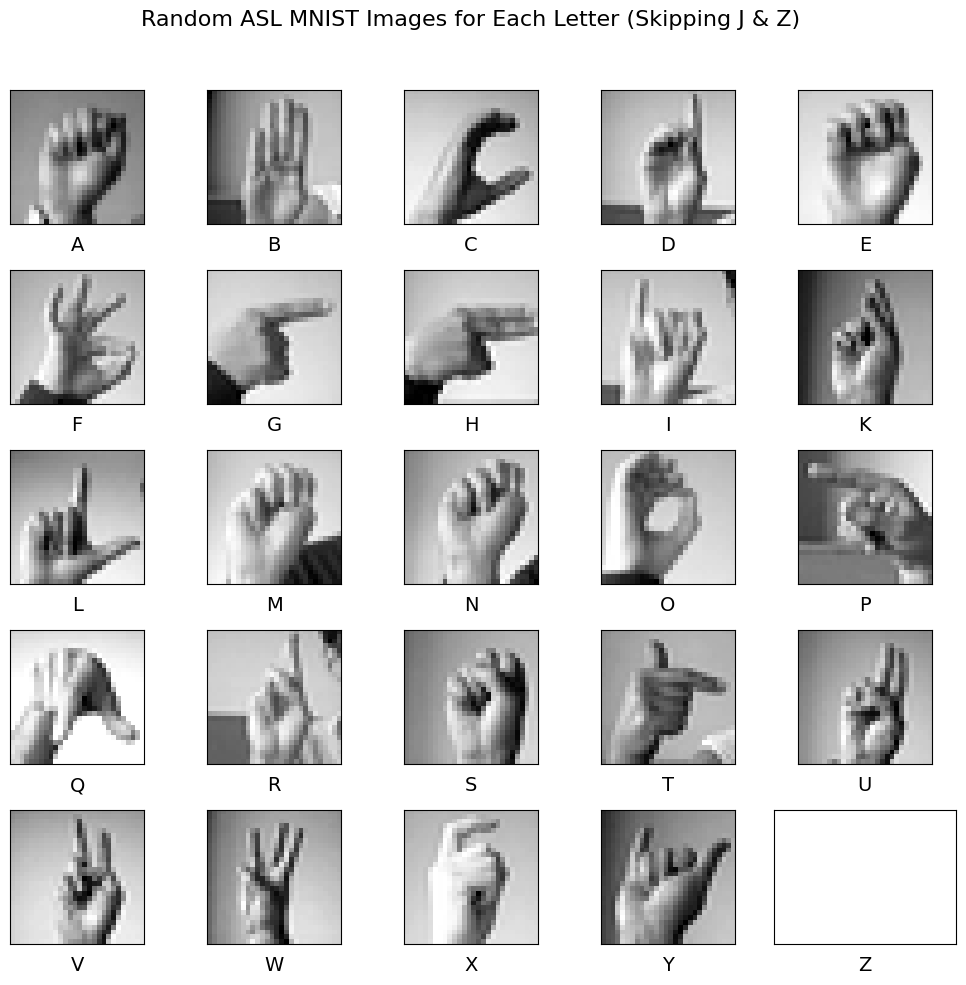

In [17]:
def visualize_all_asl_letters(df):
    """
    Selects and visualizes a random ASL MNIST image for each letter (A-Y, excluding J and Z),
    keeping the letter labels at the bottom of each image.
    
    Parameters:
        df (pd.DataFrame): The ASL MNIST dataset, where the first column is 'label' 
                           and the rest are pixel values (28x28 image).
    """
    # Set up a 5x5 grid for visualization (24 letters)
    fig, axes = plt.subplots(5, 5, figsize=(10, 10))
    fig.suptitle("Random ASL MNIST Images for Each Letter (Skipping J & Z)", fontsize=16)

    # Iterate through dataset labels (0-23), correctly skipping J (9) and Z (23)
    for i, ax in enumerate(axes.flat):
        label = i  # The dataset label

        # Skip 'J' (9) and 'Z' (23)
        asl_letter = chr(label + 65) if label < 9 else chr(label + 66)

        # Filter dataset for images of this label
        class_images = df[df['label'] == label]

        if class_images.empty:
            ax.set_xticks([])  # Remove axes
            ax.set_yticks([])
            ax.text(0.5, -0.2, asl_letter, size=14, ha='center', transform=ax.transAxes)
            continue

        # Select a random image
        random_index = np.random.randint(0, len(class_images))
        image = class_images.iloc[random_index, 1:].values.reshape(28, 28)

        # Display the image
        ax.imshow(image, cmap='gray')
        ax.set_xticks([])  # Remove x-axis
        ax.set_yticks([])  # Remove y-axis

        # Keep the letter at the bottom
        ax.text(0.5, -0.2, asl_letter, size=14, ha='center', transform=ax.transAxes)

    plt.tight_layout(rect=[0, 0, 1, 0.95])
    plt.show()
visualize_all_asl_letters(Train)

In [ ]:
import pandas as pd
import numpy as np
import torch
from sklearn.decomposition import PCA
from simple_model import SoftmaxClassifer

''' 
Observing if feature reduction affects final test accuracy
'''

train_data = pd.read_csv('sign_mnist_train.csv')
test_data = pd.read_csv('sign_mnist_test.csv')

# Adjust labels
train_data['label'] = train_data['label'].apply(lambda x: x - 1 if x > 9 else x)
test_data['label'] = test_data['label'].apply(lambda x: x - 1 if x > 9 else x)

train_data = train_data.to_numpy(dtype=np.float32)
test_data = test_data.to_numpy(dtype=np.float32)

y_train = train_data[:, 0]  # Labels for train
X_train = train_data[:, 1:]  # Features for train

y_test = test_data[:, 0]  # Labels for test
X_test = test_data[:, 1:]  # Features for test

# Normalize pixel values
X_train = X_train / 255.0
X_test = X_test / 255.0

pca = PCA(n_components=0.95)
X_train_pca = pca.fit_transform(X_train)
X_test_pca = pca.transform(X_test)  

print(f"Train shape after PCA: {X_train_pca.shape}")
print(f"Test shape after PCA: {X_test_pca.shape}")

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

X_train_tensor = torch.from_numpy(X_train_pca).float().to(device)
y_train_tensor = torch.from_numpy(y_train).long().to(device)

X_test_tensor = torch.from_numpy(X_test_pca).float().to(device)
y_test_tensor = torch.from_numpy(y_test).long().to(device)

# Initialize and train model
model = SoftmaxClassifer(X_train_pca.shape[1], 24).to(device)
model.train_model(train_X=X_train_tensor, train_y=y_train_tensor, num_epochs=100, lr=0.01, batch_size=10)
model.test_model(X_test_tensor, y_test_tensor)


Train shape after PCA: (27455, 113)
Test shape after PCA: (7172, 113)
Epoch 10 / 100: 0.6403738260269165
Epoch 20 / 100: 0.38531294465065
Epoch 30 / 100: 0.2501829266548157
Epoch 40 / 100: 0.1787574738264084
Epoch 50 / 100: 0.7310330867767334
Epoch 60 / 100: 0.43167644739151
Epoch 70 / 100: 0.07243888080120087
Epoch 80 / 100: 0.2567344307899475
Epoch 90 / 100: 0.28116482496261597
Epoch 100 / 100: 0.18677707016468048
Test accuracy: 0.6982710540992749


0.6982710540992749

Train shape after PCA: (27455, 2)


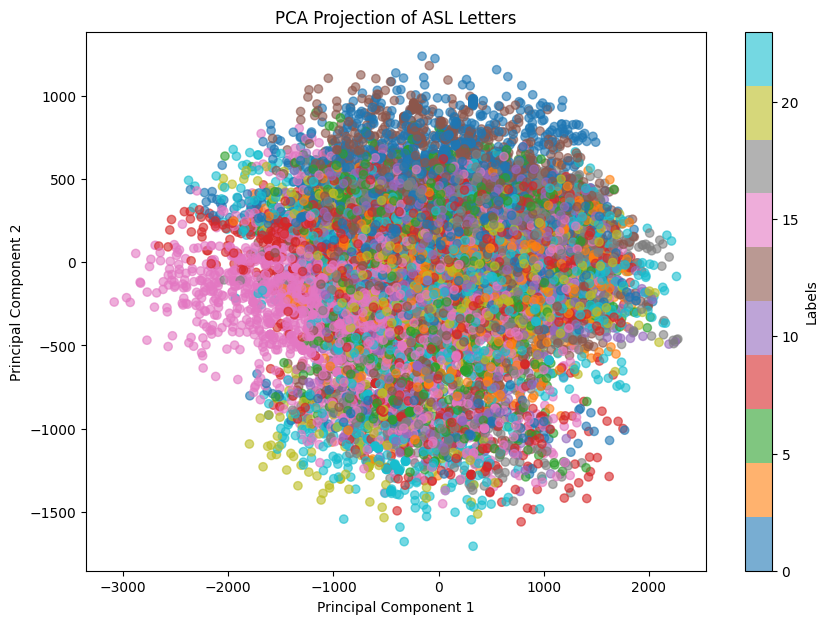

In [38]:
'''
Reducing features to 2 features with PCA and visualizing data
'''
pca_data = pd.read_csv('sign_mnist_train.csv')
pca_data['label'] = pca_data['label'].apply(lambda x: x - 1 if x > 9 else x)
pca_data = pca_data.to_numpy(dtype=np.float32)

y_train = pca_data[:, 0]  # Labels for train
X_train = pca_data[:, 1:]  # Features for train

pca = PCA(n_components=2)
X_train_pca = pca.fit_transform(X_train)
print(f"Train shape after PCA: {X_train_pca.shape}")

# Scatter plot of PCA components
plt.figure(figsize=(10, 7))
scatter = plt.scatter(X_train_pca[:, 0], X_train_pca[:, 1], c=y_train, cmap='tab10', alpha=0.6)
plt.colorbar(scatter, label="Labels")
plt.xlabel("Principal Component 1")
plt.ylabel("Principal Component 2")
plt.title("PCA Projection of ASL Letters")
plt.show()

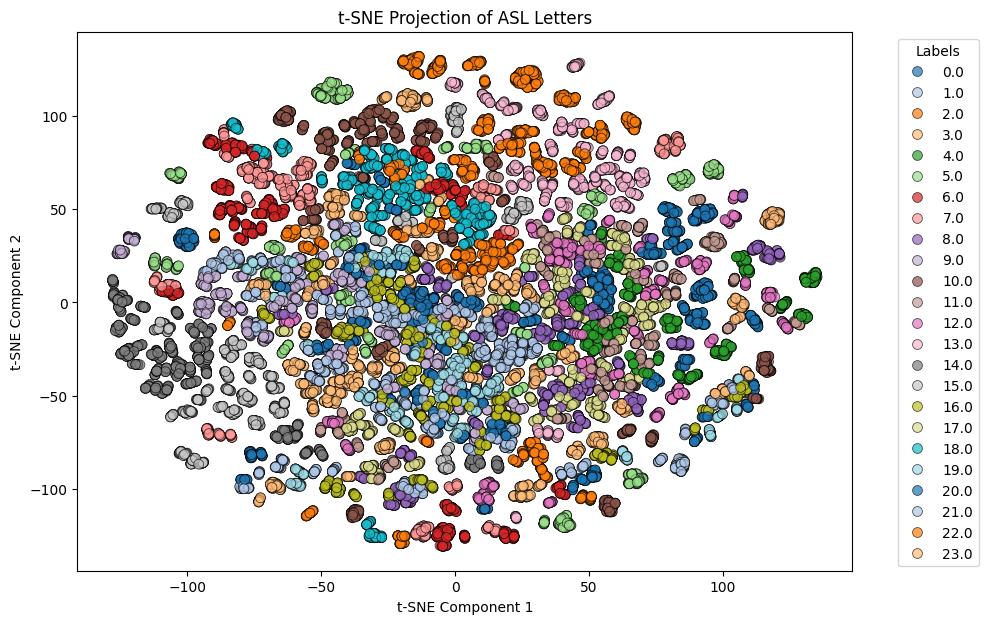

In [39]:
from sklearn.manifold import TSNE
import seaborn as sns
import matplotlib.pyplot as plt

# Apply t-SNE
tsne = TSNE(n_components=2, perplexity=30, random_state=42)
X_train_tsne = tsne.fit_transform(X_train)

# Scatter plot
plt.figure(figsize=(10, 7))
sns.scatterplot(x=X_train_tsne[:, 0], y=X_train_tsne[:, 1], hue=y_train, palette='tab20', alpha=0.7, edgecolor="k", s=50)
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left', title="Labels")
plt.xlabel("t-SNE Component 1")
plt.ylabel("t-SNE Component 2")
plt.title("t-SNE Projection of ASL Letters")
plt.show()


In [8]:
'''
Calculating baseline performance
'''

# Separate labels (y) and features (X)
y_train = Train.iloc[:, 0]  # First column as labels
y_test = Test.iloc[:, 0]    # First column as labels

# Assume y_train and y_test are Pandas Series containing the labels
most_frequent_class = y_train.value_counts().idxmax()  # Find most common class

print(f'Most frequent class: {most_frequent_class}')

# Predict the most frequent class for all test samples
y_pred_baseline = pd.Series(most_frequent_class, index=y_test.index)

# Compute accuracy
baseline_accuracy = (y_pred_baseline == y_test).mean()
print(f"Baseline Accuracy: {baseline_accuracy}")


Most frequent class: 16
Baseline Accuracy: 0.020078081427774678
